In [1]:
import os, sys, numpy
import cooling
import cirq_google
import matplotlib.pyplot as plt
import numpy as np

/opt/anaconda3/envs/quspin2/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.14) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


The first level of the cooling package is given by the "<span style="color:blue">CoolingDevice</span>
" and "<span style="color:blue">Lattice</span>" objects. The CoolingDevice specifies the system and bath qubits and their connectivity. It can be initialised from either a pre-build cirq Device, in which case it inherits the Device geometry (but the user must specify which qubits belong to the "system" and to the "bath"); or it can be initialised from a Lattice object. 

The Lattice is a user-build structure handling the system qubit geometry and connectivity. Several pre-built lattices can be found in the lattice folder, for example ChainLattice1D and SquareLattice2D. A new lattice (e.g. Kagome) should be easy to add following the examples in that folder. If CoolingDevice is created from a cirq Device, the lattice is a GraphLattice which inherits the Device graph geometry. The Lattice does not enforce a qubit geometry for the bath qubits: to model constrained system-bath geometries in 2D (such as the Sycamore device below), the user may want to define a cirq Device first.

The lattice provides a method, <span style="color:red">lattice.bond_colouring</span>, which partitions bonds into disjoint sets (i.e. commuting bonds) which will be used later for evolution. The CoolingDevice can be visualised via the <span style="color:red">device.draw</span> method. Below are examples setting up the CoolingDevice for a 6x6 square lattice with periodic boundaries, a 7x7 triangular lattice, and Google's 54 qubit Sycamore device.

Text(0.5, 1.0, 'Sycamore device')

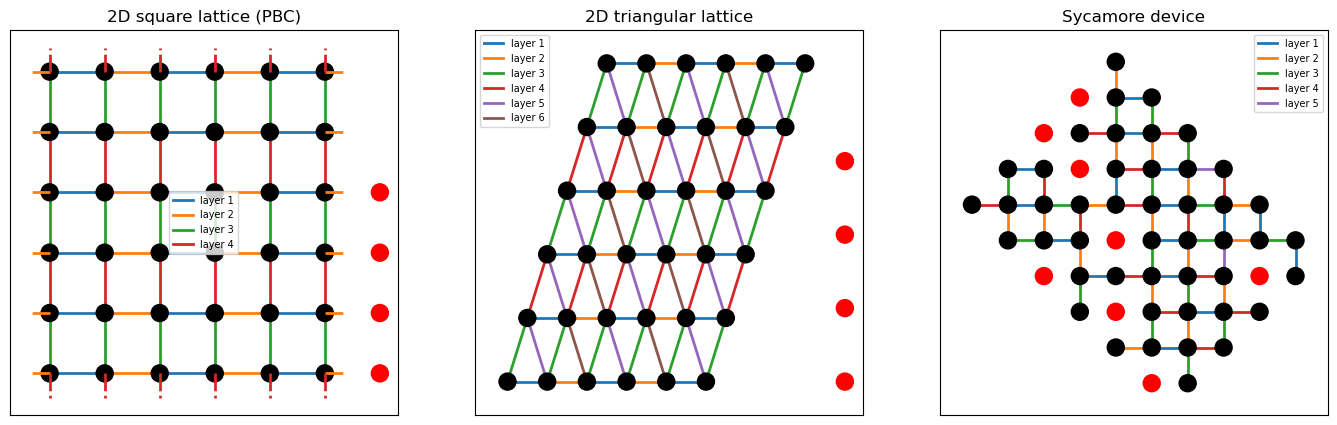

In [2]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(17,5))

# 2D square lattice (6x6, PBC) with 4 bath qubits

Lx = 6
Ly = 6
pbc_x = True
pbc_y = True

lattice = cooling.SquareLattice2D(Lx, Ly, pbc_x=pbc_x, pbc_y=pbc_y)  ### setup the lattice
device1 = cooling.CoolingDevice.from_lattice(lattice, Nb=4)  ### initialise the CoolingDevice from lattice
device1.draw(ax=ax1) # visualise the device
ax1.set_title("2D square lattice (PBC)")

# 2D triangular lattice (6x6)

Lx = 6
Ly = 6
pbc_x = False
pbc_y = False

lattice = cooling.TriangularLattice2D(Lx, Ly, pbc_x=pbc_x, pbc_y=pbc_y)  ### setup the lattice
device2 = cooling.CoolingDevice.from_lattice(lattice, Nb=4)  ### initialise the CoolingDevice from lattice
device2.draw(ax=ax2) # visualise the device
ax2.set_title("2D triangular lattice")


# 2D Sycamore device (54 qubits) with 8 bath qubits

google_device = cirq_google.Sycamore 
qs = sorted(google_device.metadata.qubit_set)
bath_qubits   = [qs[0], qs[7], qs[12], qs[18], qs[23], qs[40], qs[45], qs[50]]
system_qubits = [q for q in qs if q not in bath_qubits] 

device3 = cooling.CoolingDevice.from_cirq_device(google_device, system_qubits, bath_qubits) ### initialise from Device
device3.draw(ax3)  # visualise the device
ax3.set_title("Sycamore device")


The next level defines the system <span style="color:blue">Model</span>. This is essentially a list of couplings and on-site field terms (<span style="color:red">model.coupling_lists</span>), which defines both the model Hamiltonian (<span style="color:red">model.hamiltonian</span>) and the system gate evolution (<span style="color:red">model.system_layer</span>) which will be implemented in the circuit. The Model takes a <span style="color:blue">CoolingDevice</span> as input which defines the model geometry. Once the coupling list is defined, the base class automatically constructs the Hamiltonian and system_layer lists. 

At the moment the couplings must be any of 'XX', 'YY', 'ZZ', 'X', 'Y', 'Z', and the system_layer is built accordingly by exponentiating these in the order defined by coupling_list, and using the lattice.bond_colouring. If the user wants to implement a different gate decomposition, e.g. native Heisenberg interactions, they can overwrite <span style="color:red">model.build_system_layer</span> in the subclass. More models can easily be created following the Ising and Heisenberg templates. We show an example below for the Heisenberg chain, visualised with the <span style="color:red">model.draw</span> method.

In [3]:
L = 6
pbc = True
model_params = {"Jxx":1, "Jyy":1., "Jzz":0.5} ### Heisenberg model parameters

lattice = cooling.ChainLattice1D(L, pbc=pbc) 
device = cooling.CoolingDevice.from_lattice(lattice) 
model = cooling.HeisenbergModel(device, model_params) ### define a Heisenberg model on the device
print(model.coupling_lists) # list of bonds {'operator': [(strength, qubit1, qubit2)]}
model.draw_model()

{'XX': [(1, 0, 1), (1, 0, 5), (1, 1, 2), (1, 2, 3), (1, 3, 4), (1, 4, 5)], 'YY': [(1.0, 0, 1), (1.0, 0, 5), (1.0, 1, 2), (1.0, 2, 3), (1.0, 3, 4), (1.0, 4, 5)], 'ZZ': [(0.5, 0, 1), (0.5, 0, 5), (0.5, 1, 2), (0.5, 2, 3), (0.5, 3, 4), (0.5, 4, 5)]}
                   ┌──────────────────┐               ┌──────────────────┐              ┌────────────────┐
s0: ───XX────────────────────XX───────────YY────────────────────YY───────────ZZ──────────────────ZZ──────────
       │                     │            │                     │            │                   │
s1: ───XX^(7/11)────XX───────┼────────────YY^(7/11)────YY───────┼────────────ZZ^0.318────ZZ──────┼───────────
                    │        │                         │        │                        │       │
s2: ───XX───────────XX^(7/11)┼────────────YY───────────YY^(7/11)┼────────────ZZ──────────ZZ^0.318┼───────────
       │                     │            │                     │            │                   │
s3: ───XX^(7/11)───

Next we define the main component of the algorithm, the <span style="color:blue">Protocol</span>. 

In [8]:
L = 4
pbc = False
model_params = {"Jxx":1, "Jyy":1., "Jzz":0.} ### Heisenberg model parameters

lattice = cooling.ChainLattice1D(L, pbc=pbc) 
device = cooling.CoolingDevice.from_lattice(lattice, Nb=2) 
model = cooling.HeisenbergModel(device, model_params) ### define a Heisenberg model on the device

protocol = cooling.DetailedBalanceProtocol(device, model, function="gaussian", gamma=0.0)
protocol.print_channel_description

coupling_geometry = {0:0, 1:L-1} # boundary cooling
aPauli = {0:protocol.pauli_angles['X'], 1:protocol.pauli_angles['Y']}
params = {"beta": .2,
          "delta": 0.5*np.pi/2,
          "h": 2,
          "theta":1.,
          "aPauli":aPauli}

filter_function = protocol.filter_function(params["beta"], params["delta"], params["h"], 5)

protocol.draw_channel(coupling_geometry, params)

Using filter function: gaussian

        DetailedBalanceProtocol channel.

        Requires:
        coupling_geometry   : dict {bath_idx: sys_idx}, system bath coupling geometry
        params              : dict {param_name: value}, channel parameters
            Required params (S = structural, sets circuit depth and must be real parameter):
                beta            : float (S) - inverse target temperature
                delta           : float (S) - trotter angle
                h               : float (S) - bath splitting
                theta           : float or sympy  — coupling strength
            Optional params:
                NT              : int (S, default 5) — filter truncation / circuit depth parameter
                aPauli          : dict {bath_idx: (az, ay)}, optional, float or sympy, defaults to XX coupling

        Returns a FrozenCircuit. If theta or aPauli carry sympy symbols the
        circuit is parameterised and resolved before simulation (allows S

┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌─────┐
b0: ───Rz(-0.5π)─────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────R───────────────────────
                                     │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │
b1: ───Rz(-0.5π)─────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX───────R──────────────
                                     │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │
s0: ───XX───────────────────YY───────XX^0─────────┼────────XX──────────────────────────────────────YY───────XX^0─────────┼────────XX──────────────────────────────────────YY───────XX^0─────────┼────────

┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌───────────────┐                                                      ┌─────┐
b0: ───Rz(-0.5π)─────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────Rz(-0.5π)─────────────────────────────────────────────────XX───────────R───────────────────────
                                     │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │                                                                      │
b1: ───Rz(-0.5π)─────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX─────────────────Rz(-0.5π)──────────────────────────────┼────────────XX───────R──────────────
                                     │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │                                                         │            │
s0: ───XX───────────────────YY───────XX^0─────────┼────────XX──────────────────────────────────────YY───────XX^0─────────┼────────XX──────────────────────────────────────YY───────XX^0─────────┼────────

In [5]:
### quick simulation test

L = 6
pbc = False
model_params = {"J":.5, "g":1., "gx":0.} ### Ising model parameters

lattice = cooling.ChainLattice1D(L, pbc=pbc) 
device = cooling.CoolingDevice.from_lattice(lattice, Nb=3) 
model = cooling.IsingModel(device, model_params) ### define a Heisenberg model on the device

protocol = cooling.DetailedBalanceProtocol(device, model, function="gaussian", gamma=0.001)

coupling_geometry = {0:0, 1:L//2, 2:L-1} 
aPauli = {0:protocol.pauli_angles['Y'], 1:protocol.pauli_angles['Y'], 2:protocol.pauli_angles['Y']}
params = {"beta": 1,
          "delta": 0.2*np.pi/2,
          "h": 2,
          "theta":.25,
          "aPauli":aPauli}

simulation = cooling.Simulation(protocol)
channel = protocol.channel(coupling_geometry, params)
record = simulation.expectation_values(channel, R=700, K=5)



100%|█████████████████████████████████████████████████████████████████████████| 5/5 [00:44<00:00,  8.97s/it]


loading pre-computed energies IsingModel_chain1D_L6_J0.500_g1.000_gx0.000_Spec


/opt/anaconda3/envs/quspin2/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/quspin2/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.0, 700.0)

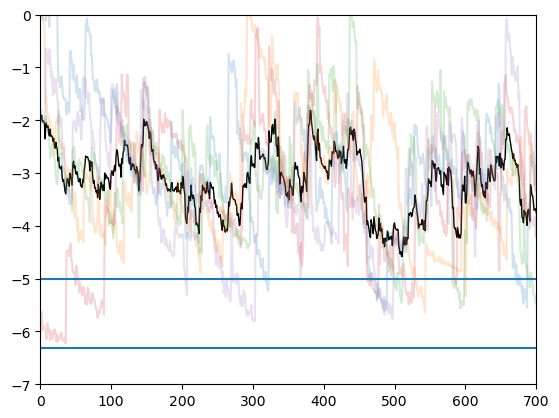

In [6]:
E_lowest, E_thermal = cooling.ThermalEnergy(model, params["beta"])

fig, ax = plt.subplots()
obs_cols = [c for c in record.columns if c not in ("repeat", "t")]
mean = record.groupby("t")[obs_cols].mean()
ax.plot(mean["H0"], lw=1, color='k')
for r, g in record.groupby("repeat"):
    ax.plot(g["t"], g["H0"], alpha=0.2)
ax.axhline(E_thermal)
ax.axhline(E_lowest[0])
ax.set_ylim(-7, 0)
ax.set_xlim(0, 700)

loading pre-computed energies IsingModel_chain1D_L6_J0.500_g1.000_gx0.000_Spec


/opt/anaconda3/envs/quspin2/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/quspin2/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(0.0, 700.0)

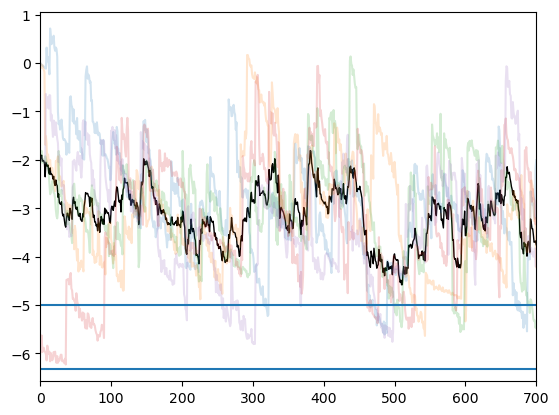

In [7]:
E_lowest, E_thermal = cooling.ThermalEnergy(model, params["beta"])

fig, ax = plt.subplots()
obs_cols = [c for c in record.columns if c not in ("repeat", "t")]
mean = record.groupby("t")[obs_cols].mean()
ax.plot(mean["H0"], lw=1, color='k')
for r, g in record.groupby("repeat"):
    ax.plot(g["t"], g["H0"], alpha=0.2)
ax.axhline(E_thermal)
ax.axhline(E_lowest[0])
# ax.set_ylim(-7, 0)
ax.set_xlim(0, 700)